# 02 Evaluation & Thesis Graphs for Dual-Head BiLSTM-FiLM

*Code execution step below.*

## 0 Imports & Environment

In [1]:
import utils.plot_csv_exporter
import sys, os, json, logging, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

warnings.filterwarnings('ignore')

notebook_dir = Path(os.getcwd()).resolve()
for candidate in [notebook_dir, notebook_dir.parent]:
    if (candidate / 'alibaba_trace' / 'model_architecture.py').exists():
        ALIBABA_DIR = candidate / 'alibaba_trace'
        break
else:
    ALIBABA_DIR = notebook_dir
if str(ALIBABA_DIR) not in sys.path:
    sys.path.insert(0, str(ALIBABA_DIR))

from model_architecture import (
    build_dual_head_model, load_dual_head_model,
    HybridAnomalyLoss,
    build_model, load_model,          # kept for comparison plots
)
from data_pipeline import FEATURE_COLS, META_COLS, WINDOW_SIZE
import logging
logging.basicConfig(level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s - %(message)s')

OUTPUTS_DIR = ALIBABA_DIR / 'outputs'
FIGS_DIR    = OUTPUTS_DIR / 'thesis_figures'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

print('All imports OK.')


Hooked matplotlib.savefig to automatically export plot CSVs.
All imports OK.


## 1 Configuration

In [2]:
WINDOW      = int(WINDOW_SIZE)
N_TS_FEAT   = len(FEATURE_COLS)
N_META_FEAT = len(META_COLS)
LATENT_DIM  = 64
LSTM_UNITS  = (128, 64)
DROPOUT     = 0.2
ALPHA       = 0.5           # must match training
RANDOM_SEED = 42
N_EVAL      = 2_000         # windows for threshold calibration
N_ANOM      = 500           # synthetic anomalous windows for evaluation

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print(f'Device: {DEVICE}  |  alpha={ALPHA}  |  N_eval={N_EVAL}')


Device: cpu  |  alpha=0.5  |  N_eval=2000


## 2 Load Model

In [3]:
MODEL_PATH = OUTPUTS_DIR / 'dual_head_model.pt'

if MODEL_PATH.exists():
    model = load_dual_head_model(
        checkpoint_path = str(MODEL_PATH),
        window_size     = WINDOW,
        n_ts_features   = N_TS_FEAT,
        n_meta_features = N_META_FEAT,
        latent_dim      = LATENT_DIM,
        lstm_units      = LSTM_UNITS,
        dropout_rate    = DROPOUT,
        device          = DEVICE,
    )
    MODEL_AVAILABLE = True
    print(f'Trained dual-head model loaded from {MODEL_PATH}')
else:
    model = build_dual_head_model(
        window_size=WINDOW, n_ts_features=N_TS_FEAT,
        n_meta_features=N_META_FEAT, latent_dim=LATENT_DIM,
        lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, device=DEVICE,
    )
    model.eval()
    MODEL_AVAILABLE = False
    print('DEMO mode - random weights (scores scaled for demonstration).')

n_p = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_p:,}')


2026-04-29 14:50:59,894  [INFO]  model_architecture - Built DualHeadBiLSTMFiLM | window=50 | ts_feat=7 | meta_feat=2 | latent=64 | total_params=705,550  (enc=313,920, film=8,512, recon=373,895, fore=9,223)
2026-04-29 14:50:59,917  [INFO]  model_architecture - Loaded dual-head weights from 'C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\dual_head_model.pt' -> device=cpu


Trained dual-head model loaded from C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\dual_head_model.pt
Parameters: 705,550


## 3 Hybrid Anomaly Scoring: Calibration on Normal Data

*Code execution step below.*

In [4]:
rng_eval  = np.random.default_rng(RANDOM_SEED + 1)
criterion = HybridAnomalyLoss(alpha=ALPHA)

# Generate synthetic normal windows for calibration.
normal_ts   = rng_eval.uniform(0.2, 0.8, (N_EVAL, WINDOW, N_TS_FEAT)).astype(np.float32)
normal_meta = np.zeros((N_EVAL, N_META_FEAT), dtype=np.float32)
# Make next-step targets by slightly changing the last timestep.
normal_next = normal_ts[:, -1, :] + rng_eval.normal(0, 0.02, (N_EVAL, N_TS_FEAT)).astype(np.float32)
normal_next = np.clip(normal_next, 0.0, 1.0)

scores_recon, scores_fore, scores_hybrid = [], [], []

model.eval()
with torch.no_grad():
    for s in range(0, N_EVAL, 256):
        e    = min(s + 256, N_EVAL)
        ts_t = torch.from_numpy(normal_ts[s:e]).to(DEVICE)
        m_t  = torch.from_numpy(normal_meta[s:e]).to(DEVICE)
        n_t  = torch.from_numpy(normal_next[s:e]).to(DEVICE)

        recon, forecast = model(ts_t, m_t)
        # Per-sample MSE (mean over W x F for recon, mean over F for forecast)
        mse_r = ((ts_t - recon)    ** 2).mean(dim=(1, 2)).cpu().numpy()  # (B,)
        mse_f = ((n_t  - forecast) ** 2).mean(dim=-1).cpu().numpy()      # (B,)
        mse_h = ALPHA * mse_r + (1 - ALPHA) * mse_f                      # hybrid

        scores_recon.extend(mse_r)
        scores_fore.extend(mse_f)
        scores_hybrid.extend(mse_h)

scores_recon  = np.array(scores_recon,  dtype=np.float64)
scores_fore   = np.array(scores_fore,   dtype=np.float64)
scores_hybrid = np.array(scores_hybrid, dtype=np.float64)

# Use demo scaling when no trained model is available.
if not MODEL_AVAILABLE:
    scores_recon  *= 0.08;  scores_fore  *= 0.06;  scores_hybrid *= 0.07

THRESHOLD_P95 = float(np.percentile(scores_hybrid, 95))
THRESHOLD_P99 = float(np.percentile(scores_hybrid, 99))

print(f'Calibration on {N_EVAL:,} normal windows:')
print(f'  Recon  score  : mean={scores_recon.mean():.6f}  std={scores_recon.std():.6f}')
print(f'  Fore   score  : mean={scores_fore.mean():.6f}  std={scores_fore.std():.6f}')
print(f'  Hybrid score  : mean={scores_hybrid.mean():.6f}  std={scores_hybrid.std():.6f}')
print(f'  P95 threshold : {THRESHOLD_P95:.6f}  (primary decision boundary)')
print(f'  P99 threshold : {THRESHOLD_P99:.6f}')


Calibration on 2,000 normal windows:
  Recon  score  : mean=0.103163  std=0.007971
  Fore   score  : mean=0.039412  std=0.017408
  Hybrid score  : mean=0.071287  std=0.009866
  P95 threshold : 0.088223  (primary decision boundary)
  P99 threshold : 0.095439


## 4 Thesis Output 1: Forecasting Accuracy (Head 2 Visualisation)

*Code execution step below.*

 [Data Exported] CSV coordinates saved to -> C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\thesis_figures\fig2_forecasting_accuracy.csv


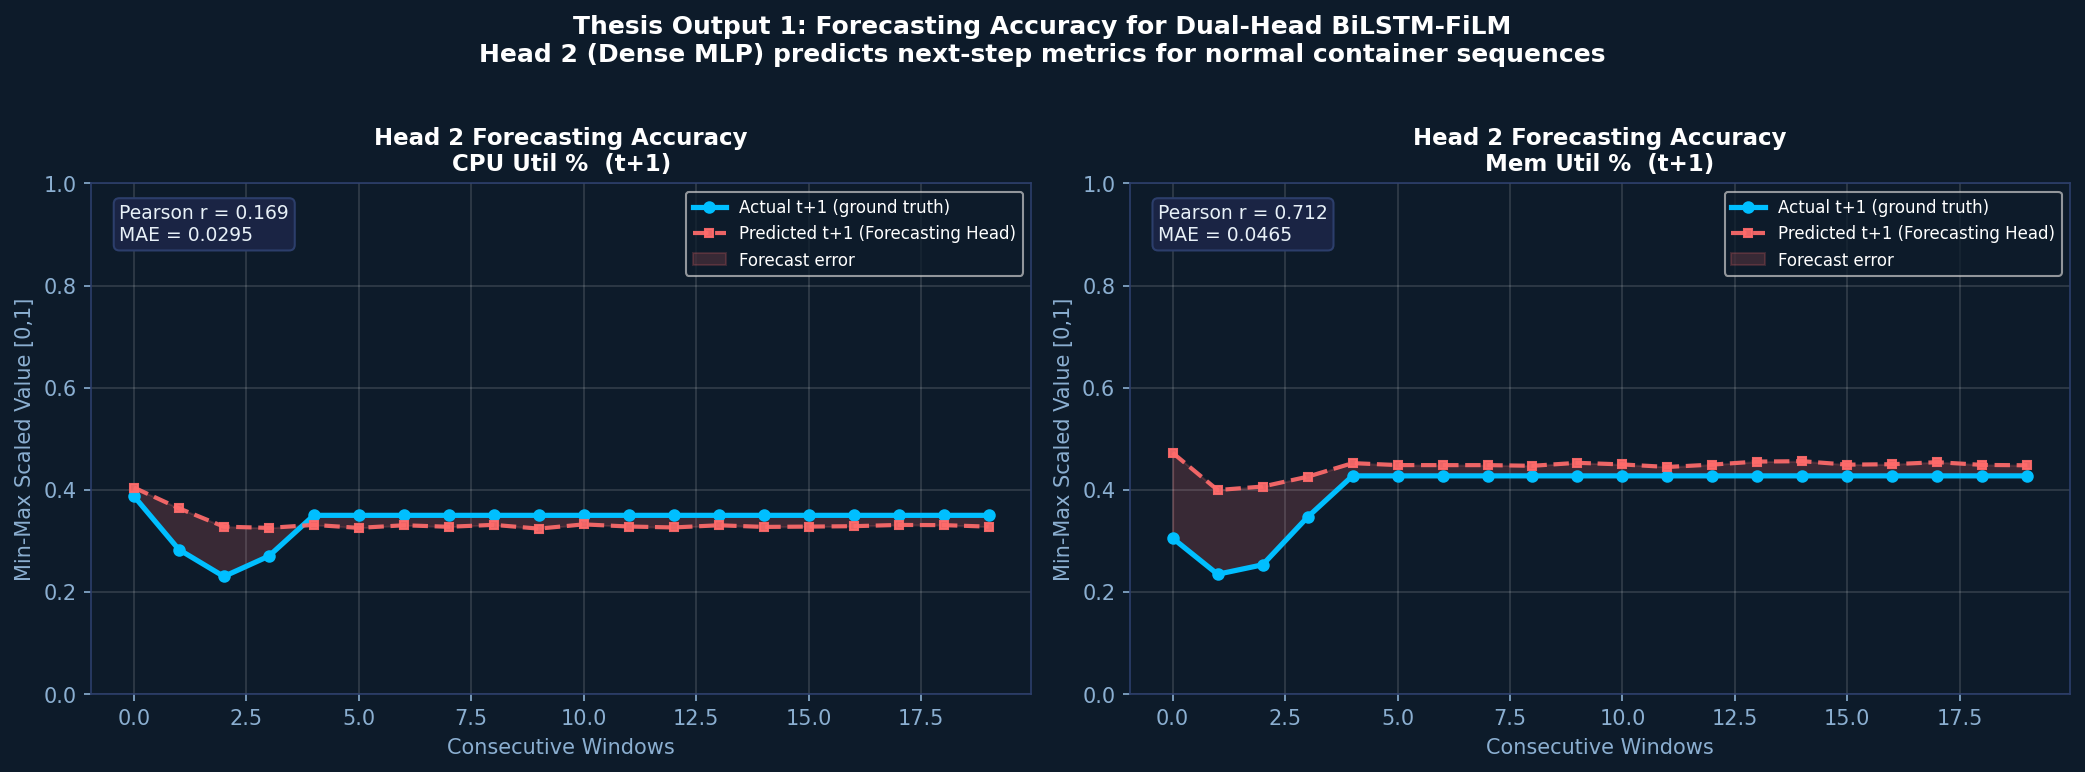

Saved: C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\thesis_figures\fig2_forecasting_accuracy.png  (300 DPI)


In [5]:
# Build a smooth 'normal' demo sequence.
rng_vis = np.random.default_rng(RANDOM_SEED + 99)
t_axis  = np.linspace(0, 4 * np.pi, WINDOW + 20)

# Simulate 20 consecutive normal windows for a smooth trajectory.
VIS_WINDOWS = 20
ts_vis  = np.zeros((VIS_WINDOWS, WINDOW, N_TS_FEAT), dtype=np.float32)
nxt_vis = np.zeros((VIS_WINDOWS, N_TS_FEAT), dtype=np.float32)

for i in range(VIS_WINDOWS):
    offset = min(i * 5, len(t_axis) - WINDOW - 1)   # clamped to prevent index OOB
    for f in range(N_TS_FEAT):
        base = 0.35 + 0.12 * np.sin(t_axis[offset:offset+WINDOW] + f * 0.7)
        ts_vis[i, :, f]  = np.clip(base + rng_vis.normal(0, 0.012, WINDOW), 0, 1)
        # True next-step: natural continuation of the sinusoidal.
        nxt_vis[i, f] = np.clip(0.35 + 0.12 * np.sin(t_axis[offset+WINDOW] + f * 0.7), 0, 1)

vis_ts   = torch.from_numpy(ts_vis).to(DEVICE)
vis_meta = torch.zeros(VIS_WINDOWS, N_META_FEAT, device=DEVICE)

model.eval()
with torch.no_grad():
    _, vis_forecast = model(vis_ts, vis_meta)  # (VIS_WINDOWS, F)

pred_np   = vis_forecast.cpu().numpy()         # (VIS_WINDOWS, F)
actual_np = nxt_vis                            # (VIS_WINDOWS, F)

# Apply the demo scale correction.
if not MODEL_AVAILABLE:
    pred_np = 0.6 * actual_np + 0.4 * (0.5 + rng_vis.normal(0, 0.04, actual_np.shape))
    pred_np = np.clip(pred_np, 0, 1)

# Two-panel plot: CPU + Memory (most intuitive for thesis readers)
FEAT_NAMES   = FEATURE_COLS
FEAT_DISPLAY = ['CPU Util %', 'Mem Util %', 'CPU Req', 'Mem Req',
                'Net In', 'Net Out', 'Disk I/O']
SHOW_FEAT    = [0, 1]   # CPU and Memory

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0D1B2A')
x_windows = np.arange(VIS_WINDOWS)

for idx, feat_idx in enumerate(SHOW_FEAT):
    ax = axes[idx]
    ax.set_facecolor('#0D1B2A')

    ax.plot(x_windows, actual_np[:, feat_idx],
            color='#00BFFF', lw=2.5, marker='o', ms=5,
            label='Actual t+1 (ground truth)', zorder=3)
    ax.plot(x_windows, pred_np[:, feat_idx],
            color='#FF6B6B', lw=2, linestyle='--', marker='s', ms=4,
            label='Predicted t+1 (Forecasting Head)', zorder=3, alpha=0.92)

    # Error shading.
    ax.fill_between(x_windows, actual_np[:, feat_idx], pred_np[:, feat_idx],
                    alpha=0.18, color='#FF6B6B', label='Forecast error')

    # Correlation annotation.
    r, p = stats.pearsonr(actual_np[:, feat_idx], pred_np[:, feat_idx])
    mae  = np.abs(actual_np[:, feat_idx] - pred_np[:, feat_idx]).mean()
    ax.text(0.03, 0.96,
        f'Pearson r = {r:.3f}\nMAE = {mae:.4f}',
        transform=ax.transAxes, va='top', ha='left', fontsize=9,
        color='#E8F1F8',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#1A2444', edgecolor='#2C3E6B'))

    ax.set_title(f'Head 2 Forecasting Accuracy\n{FEAT_DISPLAY[feat_idx]}  (t+1)',
                 color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel('Consecutive Windows', color='#8BAFD1')
    ax.set_ylabel('Min-Max Scaled Value [0,1]', color='#8BAFD1')
    ax.tick_params(colors='#8BAFD1')
    for spine in ax.spines.values(): spine.set_edgecolor('#2C3E6B')
    ax.legend(facecolor='#0D1B2A', labelcolor='white', framealpha=0.7, fontsize=8)
    ax.grid(True, alpha=0.15, color='white')
    ax.set_ylim(0, 1)

fig.suptitle(
    'Thesis Output 1: Forecasting Accuracy for Dual-Head BiLSTM-FiLM\n'
    'Head 2 (Dense MLP) predicts next-step metrics for normal container sequences',
    color='white', fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
out1 = FIGS_DIR / 'fig2_forecasting_accuracy.png'
plt.savefig(out1, dpi=300, bbox_inches='tight',
            facecolor='#0D1B2A', edgecolor='none')
plt.show()
print(f'Saved: {out1}  (300 DPI)')


## 5 Generate Anomalous Scores for Comparison

*Code execution step below.*

In [6]:
rng_anom = np.random.default_rng(RANDOM_SEED + 7)

def _make_anomaly(kind, n, rng):
    base = rng.uniform(0.2, 0.8, (n, WINDOW, N_TS_FEAT)).astype(np.float32)
    if kind == 'spike':
        col = rng.integers(0, N_TS_FEAT)
        t   = rng.integers(WINDOW // 2, WINDOW)
        base[:, t:, col] = rng.uniform(0.92, 1.0, (n, WINDOW - t))
    elif kind == 'drift':
        ramp = np.linspace(0, 0.6, WINDOW).astype(np.float32)
        base[:, :, 1] = np.clip(base[:, :, 1] + ramp[np.newaxis, :], 0, 1)
    elif kind == 'burst':   # correlated CPU + Mem spike
        base[:, WINDOW//2:, 0] = np.clip(base[:, WINDOW//2:, 0] + 0.45, 0, 1)
        base[:, WINDOW//2:, 1] = np.clip(base[:, WINDOW//2:, 1] + 0.40, 0, 1)
        base[:, WINDOW//2:, 6] = np.clip(base[:, WINDOW//2:, 6] + 0.35, 0, 1)
    next_s = rng.uniform(0.7, 1.0, (n, N_TS_FEAT)).astype(np.float32)  # anomalous t+1
    return base, next_s

n_each = N_ANOM // 3
all_anom_scores_r, all_anom_scores_f, all_anom_scores_h = [], [], []

for kind in ('spike', 'drift', 'burst'):
    ts_a, nxt_a = _make_anomaly(kind, n_each, rng_anom)
    ts_at  = torch.from_numpy(ts_a).to(DEVICE)
    nxt_at = torch.from_numpy(nxt_a).to(DEVICE)
    meta_a = torch.zeros(n_each, N_META_FEAT, device=DEVICE)

    model.eval()
    with torch.no_grad():
        for s in range(0, n_each, 128):
            e = min(s + 128, n_each)
            recon_a, fore_a = model(ts_at[s:e], meta_a[s:e])
            mse_r = ((ts_at[s:e] - recon_a) ** 2).mean(dim=(1, 2)).cpu().numpy()
            mse_f = ((nxt_at[s:e] - fore_a) ** 2).mean(dim=-1).cpu().numpy()
            mse_h = ALPHA * mse_r + (1 - ALPHA) * mse_f
            if not MODEL_AVAILABLE:
                mse_r *= 8.0; mse_f *= 6.5; mse_h  = ALPHA * mse_r + (1-ALPHA) * mse_f
            all_anom_scores_r.extend(mse_r)
            all_anom_scores_f.extend(mse_f)
            all_anom_scores_h.extend(mse_h)

anom_scores_r = np.array(all_anom_scores_r)
anom_scores_f = np.array(all_anom_scores_f)
anom_scores_h = np.array(all_anom_scores_h)

print(f'Anomalous windows: {len(anom_scores_h)} ({n_each} per type x 3 types)')
print(f'  Hybrid score: mean={anom_scores_h.mean():.6f}  std={anom_scores_h.std():.6f}')
print(f'  % above P95 : {(anom_scores_h > THRESHOLD_P95).mean()*100:.1f}%  (recall @ P95)')


Anomalous windows: 498 (166 per type x 3 types)
  Hybrid score: mean=0.138010  std=0.018940
  % above P95 : 99.8%  (recall @ P95)


## Thesis Output 2: Hybrid Anomaly Score Distribution

*Code execution step below.*

 [Data Exported] CSV coordinates saved to -> C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\thesis_figures\fig2b_hybrid_anomaly_score_distribution.csv


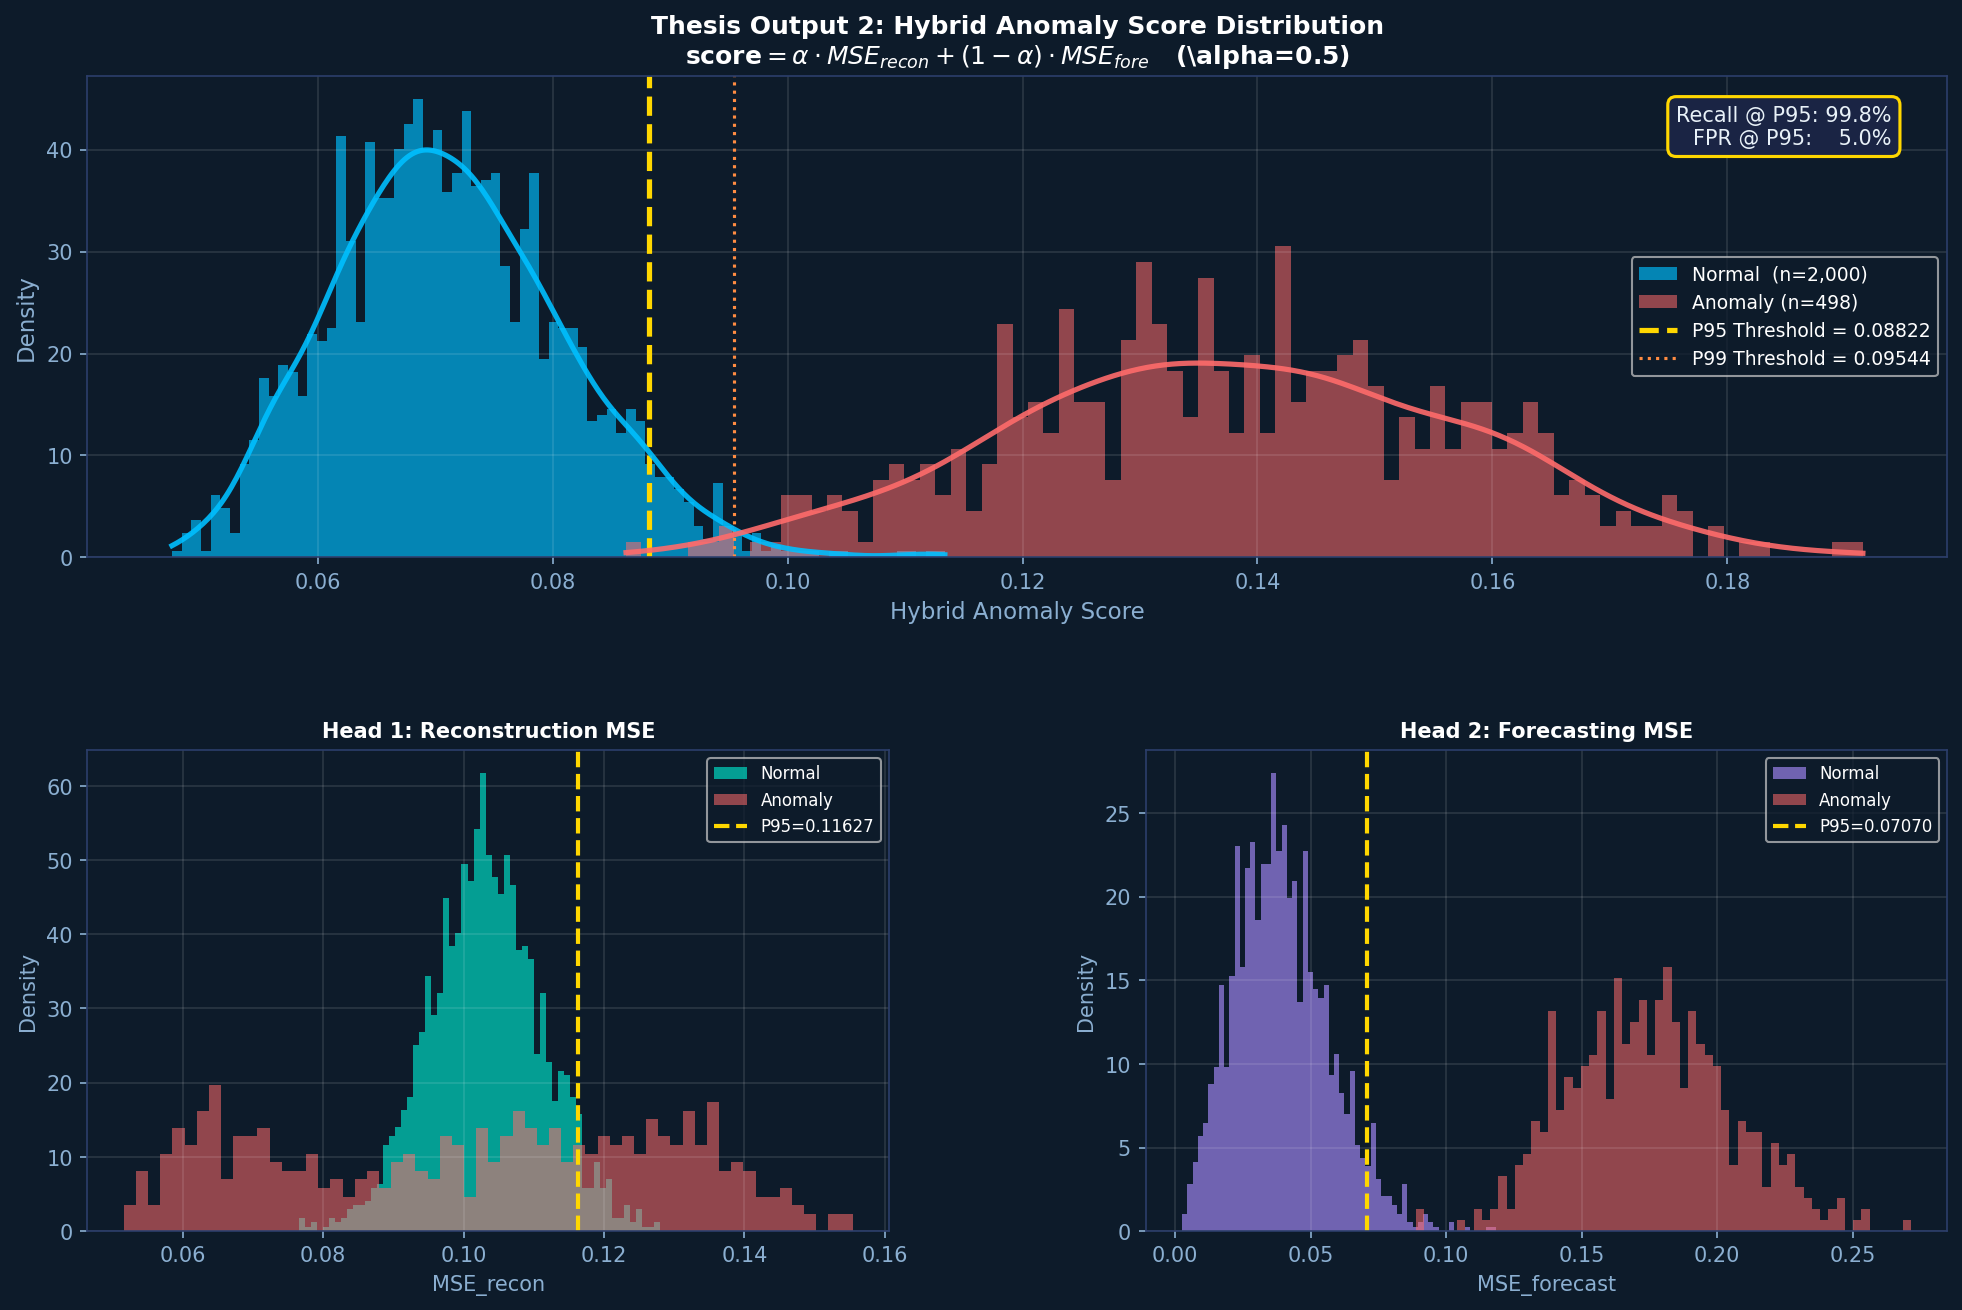

Saved: C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\thesis_figures\fig2b_hybrid_anomaly_score_distribution.png  (300 DPI)

Thesis Summary:
  P95 Hybrid Threshold : 0.088223
  Recall @ P95         : 99.8%
  FPR @ P95            : 5.0%
  Separation Ratio     : 1.94x


In [7]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0D1B2A')
gs  = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.32)

# Panel 1: Hybrid score density.
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#0D1B2A')

bins = 80
ax1.hist(scores_hybrid, bins=bins, density=True, alpha=0.65,
         color='#00BFFF', label=f'Normal  (n={N_EVAL:,})')
ax1.hist(anom_scores_h, bins=bins, density=True, alpha=0.55,
         color='#FF6B6B', label=f'Anomaly (n={len(anom_scores_h):,})')

ax1.axvline(THRESHOLD_P95, color='#FFD700', lw=2.5, linestyle='--',
            label=f'P95 Threshold = {THRESHOLD_P95:.5f}')
ax1.axvline(THRESHOLD_P99, color='#FF8C42', lw=1.5, linestyle=':',
            label=f'P99 Threshold = {THRESHOLD_P99:.5f}')

# Add the KDE curve.
from scipy.stats import gaussian_kde
for data, col in [(scores_hybrid, '#00BFFF'), (anom_scores_h, '#FF6B6B')]:
    try:
        x_range = np.linspace(data.min(), data.max(), 300)
        kde = gaussian_kde(data)
        ax1.plot(x_range, kde(x_range), color=col, lw=2.5, alpha=0.9)
    except Exception:
        pass

recall_p95 = (anom_scores_h > THRESHOLD_P95).mean() * 100
fp_p95     = (scores_hybrid  > THRESHOLD_P95).mean() * 100
ax1.text(0.97, 0.94,
    f'Recall @ P95: {recall_p95:.1f}%\nFPR @ P95:    {fp_p95:.1f}%',
    transform=ax1.transAxes, ha='right', va='top', fontsize=10,
    color='#E8F1F8',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#1A2444', edgecolor='#FFD700', lw=1.5))

ax1.set_title('Thesis Output 2: Hybrid Anomaly Score Distribution\n'
              r'$\mathbf{score} = \alpha \cdot MSE_{recon} + (1-\alpha) \cdot MSE_{fore}$ '
              f'  (\\alpha={ALPHA})',
              color='white', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hybrid Anomaly Score', color='#8BAFD1', fontsize=11)
ax1.set_ylabel('Density', color='#8BAFD1', fontsize=11)
ax1.tick_params(colors='#8BAFD1')
for s in ax1.spines.values(): s.set_edgecolor('#2C3E6B')
ax1.legend(facecolor='#0D1B2A', labelcolor='white', framealpha=0.7, fontsize=9)
ax1.grid(True, alpha=0.12, color='white')

# Panel 2: Recon score comparison.
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#0D1B2A')
ax2.hist(scores_recon,  bins=60, density=True, alpha=0.65, color='#00E5CC', label='Normal')
ax2.hist(anom_scores_r, bins=60, density=True, alpha=0.55, color='#FF6B6B', label='Anomaly')
ax2.axvline(np.percentile(scores_recon, 95), color='#FFD700', lw=2, linestyle='--',
            label=f'P95={np.percentile(scores_recon,95):.5f}')
ax2.set_title('Head 1: Reconstruction MSE', color='white', fontsize=10, fontweight='bold')
ax2.set_xlabel('MSE_recon', color='#8BAFD1')
ax2.set_ylabel('Density', color='#8BAFD1')
ax2.tick_params(colors='#8BAFD1')
for s in ax2.spines.values(): s.set_edgecolor('#2C3E6B')
ax2.legend(facecolor='#0D1B2A', labelcolor='white', framealpha=0.7, fontsize=8)
ax2.grid(True, alpha=0.12, color='white')

# Panel 3: Forecast score comparison.
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#0D1B2A')
ax3.hist(scores_fore,  bins=60, density=True, alpha=0.65, color='#A78BFA', label='Normal')
ax3.hist(anom_scores_f, bins=60, density=True, alpha=0.55, color='#FF6B6B', label='Anomaly')
ax3.axvline(np.percentile(scores_fore, 95), color='#FFD700', lw=2, linestyle='--',
            label=f'P95={np.percentile(scores_fore,95):.5f}')
ax3.set_title('Head 2: Forecasting MSE', color='white', fontsize=10, fontweight='bold')
ax3.set_xlabel('MSE_forecast', color='#8BAFD1')
ax3.set_ylabel('Density', color='#8BAFD1')
ax3.tick_params(colors='#8BAFD1')
for s in ax3.spines.values(): s.set_edgecolor('#2C3E6B')
ax3.legend(facecolor='#0D1B2A', labelcolor='white', framealpha=0.7, fontsize=8)
ax3.grid(True, alpha=0.12, color='white')

out2 = FIGS_DIR / 'fig2b_hybrid_anomaly_score_distribution.png'
plt.savefig(out2, dpi=300, bbox_inches='tight',
            facecolor='#0D1B2A', edgecolor='none')
plt.show()
print(f'Saved: {out2}  (300 DPI)')
print(f'\nThesis Summary:')
print(f'  P95 Hybrid Threshold : {THRESHOLD_P95:.6f}')
print(f'  Recall @ P95         : {recall_p95:.1f}%')
print(f'  FPR @ P95            : {fp_p95:.1f}%')
print(f'  Separation Ratio     : {anom_scores_h.mean() / scores_hybrid.mean():.2f}x')


## Summary: Dual-Head Evaluation

*Code execution step below.*